# Selfish vs Altruistic Agents

This experiment involves two agents engaged in travel, each with distinct preferences: selfish agents seek to maximize their individual travel time, while altruistic agents aim to maximize the average travel time between them. The chosen origin-destination pairs for travel are deliberately distant. The experiment utilizes the Proximal Policy Optimization (PPO) algorithm for learning in both scenarios. 

## Experiment Summary

- **Network Architecture:** Utilization of the Csomor network.
- **Number of agents:** 2.
- **Number of origins:** 2.
- **Number of destinations:** 2.
- **Origin pairs:**: 279952229#0, 115604053
- **Destination pairs:**: -335062734#1, 23130852#3
- **New agents are created every:** 6 step.
- **Number of paths between origin and destination :** 3.
- **Reinforcement Learning Algorithm:** Proximal Policy Optimization (PPO)

    - **PPO Hyperparameters:**
        - *Gamma:* 0.9
        - *Learning Rate:* 1e-3
        - *Timesteps:* 1000

If we get an error in the creation of the environment we need to delete the right part of the and in utilities/path_generator.py line 27.

## Altruistic Agents

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

Add the correct parameters in the params dict.

In [11]:
number_of_paths = 3
origins = ["279952229#0", "115604053"]
destinations = ["-335062734#1", "23130852#3"]
num_agents = 2

In [12]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

{'sumo_type': 'sumo', 'sumo_config_path': 'Network_and_config/csomor1.sumocfg', 'connection_file_path': 'Network_and_config/csomor1.con.xml', 'edge_file_path': 'Network_and_config/csomor1.edg.xml', 'route_file_path': 'Network_and_config/csomor1.rou.xml', 'routes_xml_save_path': 'Network_and_config/route.rou.xml', 'paths_save_path': 'paths.csv', 'number_of_paths': 3, 'simulation_timesteps': 3600, 'beta': -0.1, 'origins': ['279952229#0', '115604053'], 'destinations': ['-335062734#1', '23130852#3']}


In [13]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [138.61457370471226, 163.39579839221975, 27.00358295297248], (0, 1): [44.15311101823132, 507.65660686680707, 82.86554119884387], (1, 0): [285.7012358631655, 112.9435624327784, 14.200902640376952], (1, 1): [3456.3921835558463, 585.6195946451909, 134.6465983094074]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 1.
Agent 1 has origin 0 and destination 1.


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [6]:
env.reward_table = []
env.actions = []
env.actions2 = []        

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [8]:
model.learn(total_timesteps=2000)

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 227 |
|    total_timesteps | 20  |
----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 0             |
|    iterations           | 2             |
|    time_elapsed         | 341           |
|    total_timesteps      | 40            |
| train/                  |               |
|    approx_kl            | 0.00036163925 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | 1.85e-05      |
|    learning_rate        | 0.001         |
|    loss                 | 5.58e+05      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00359      |
|    value_loss           | 1.71e+06      |
-------------------------------------------
-----

Reward table is:  [-117.01666666666668, -442.7583333333333, -2175.4249999999997, -723.8333333333333, -424.65, -2200.791666666667, -399.7166666666667, -424.65, -117.01666666666668, -2501.275, -399.7166666666667, -723.8333333333333, -442.7583333333333, -2501.275, -117.01666666666668, -424.65, -442.7583333333333, -142.825, -442.7583333333333, -142.825, -424.65, -723.8333333333333, -723.8333333333333, -117.01666666666668, -723.8333333333333, -2200.791666666667, -723.8333333333333, -142.825, -399.7166666666667, -2501.275, -117.01666666666668, -442.7583333333333, -399.7166666666667, -723.8333333333333, -2200.791666666667, -442.7583333333333, -142.825, -442.7583333333333, -117.01666666666668, -424.65, -2501.275, -2175.4249999999997, -2501.275, -424.65, -399.7166666666667, -424.65, -442.7583333333333, -93.025, -94.0, -233.07500000000002, -233.07500000000002, -203.46666666666667, -63.891666666666666, -1854.4833333333333, -1883.7916666666665, -63.891666666666666, -203.46666666666667, -124.358333

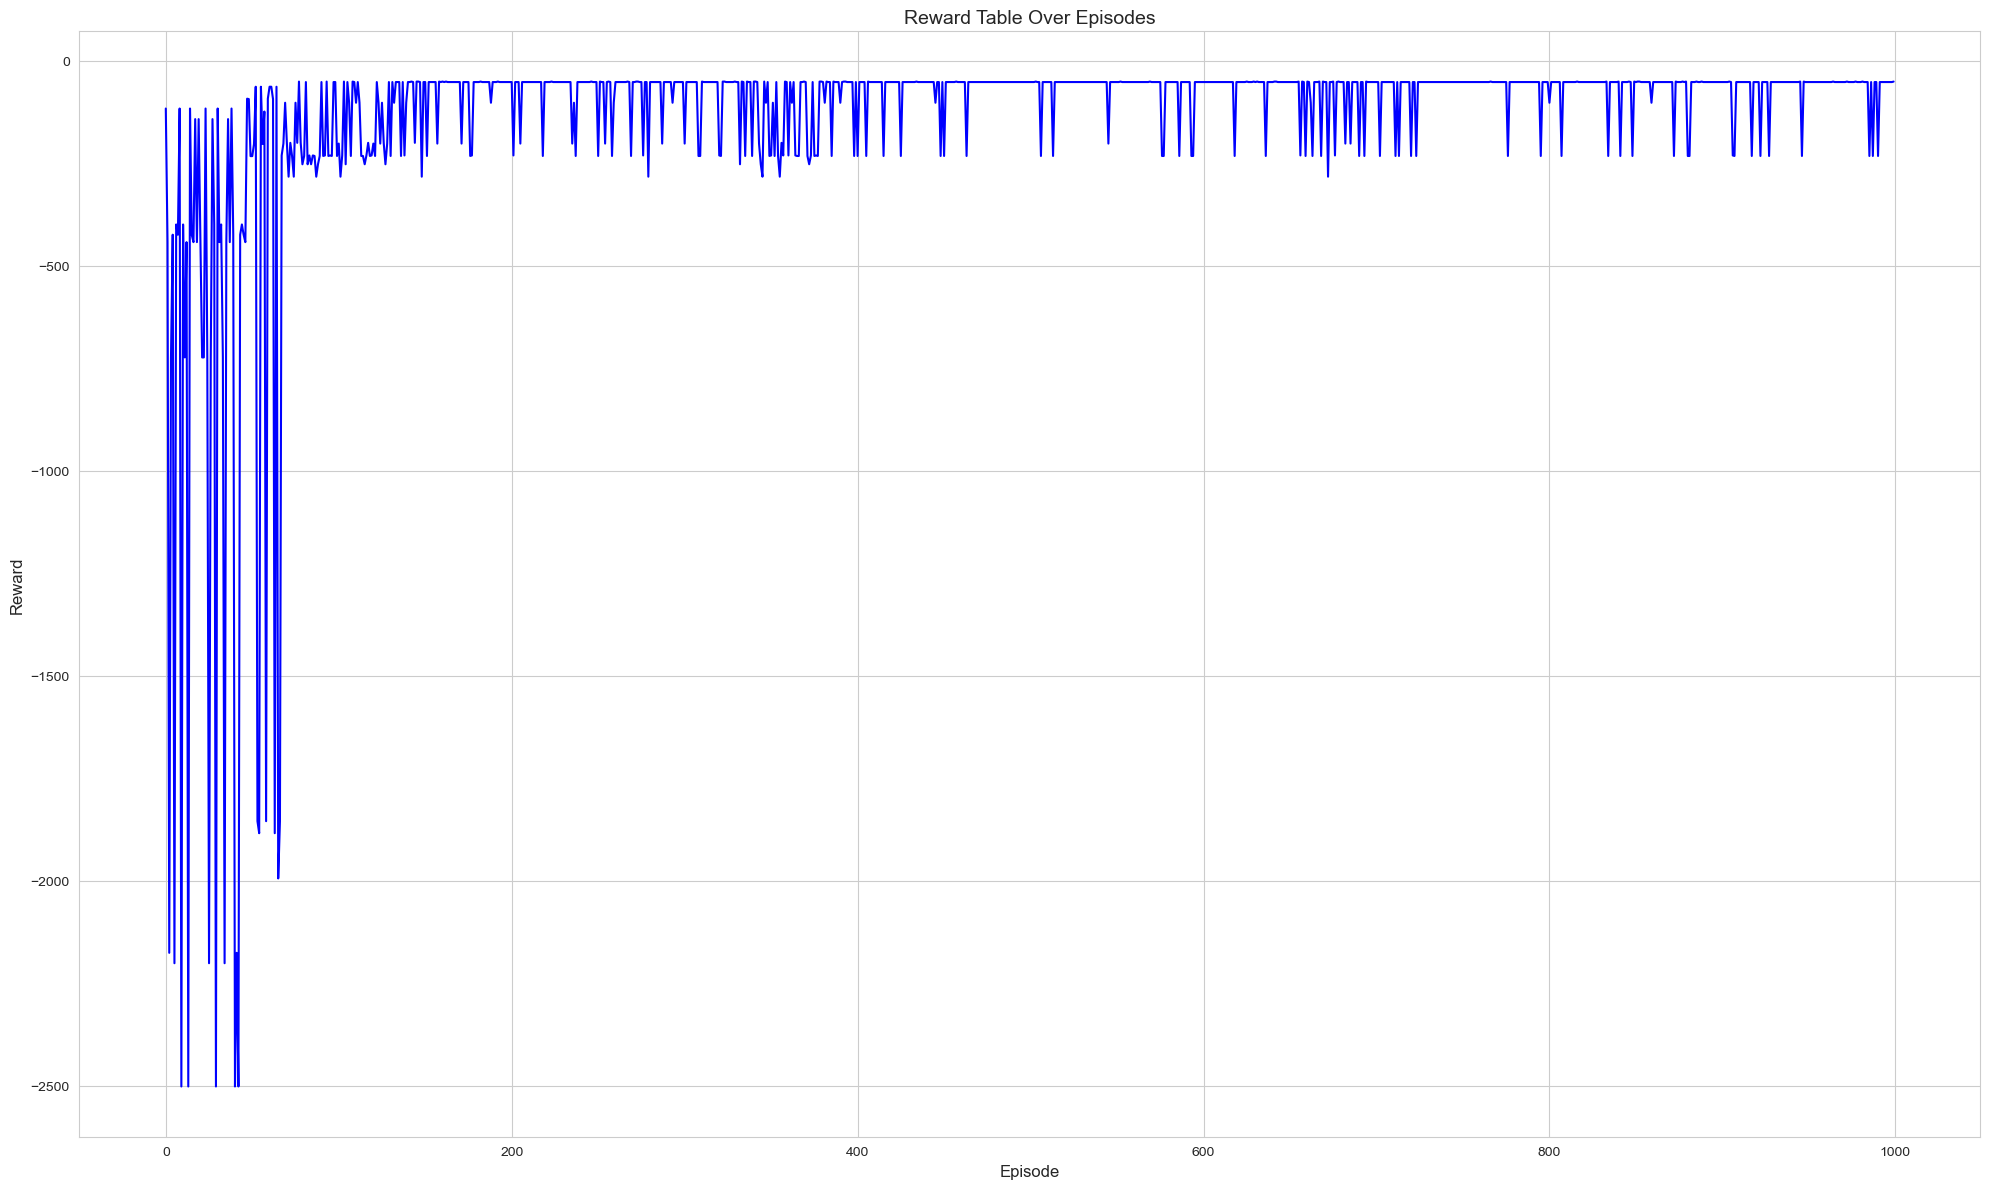

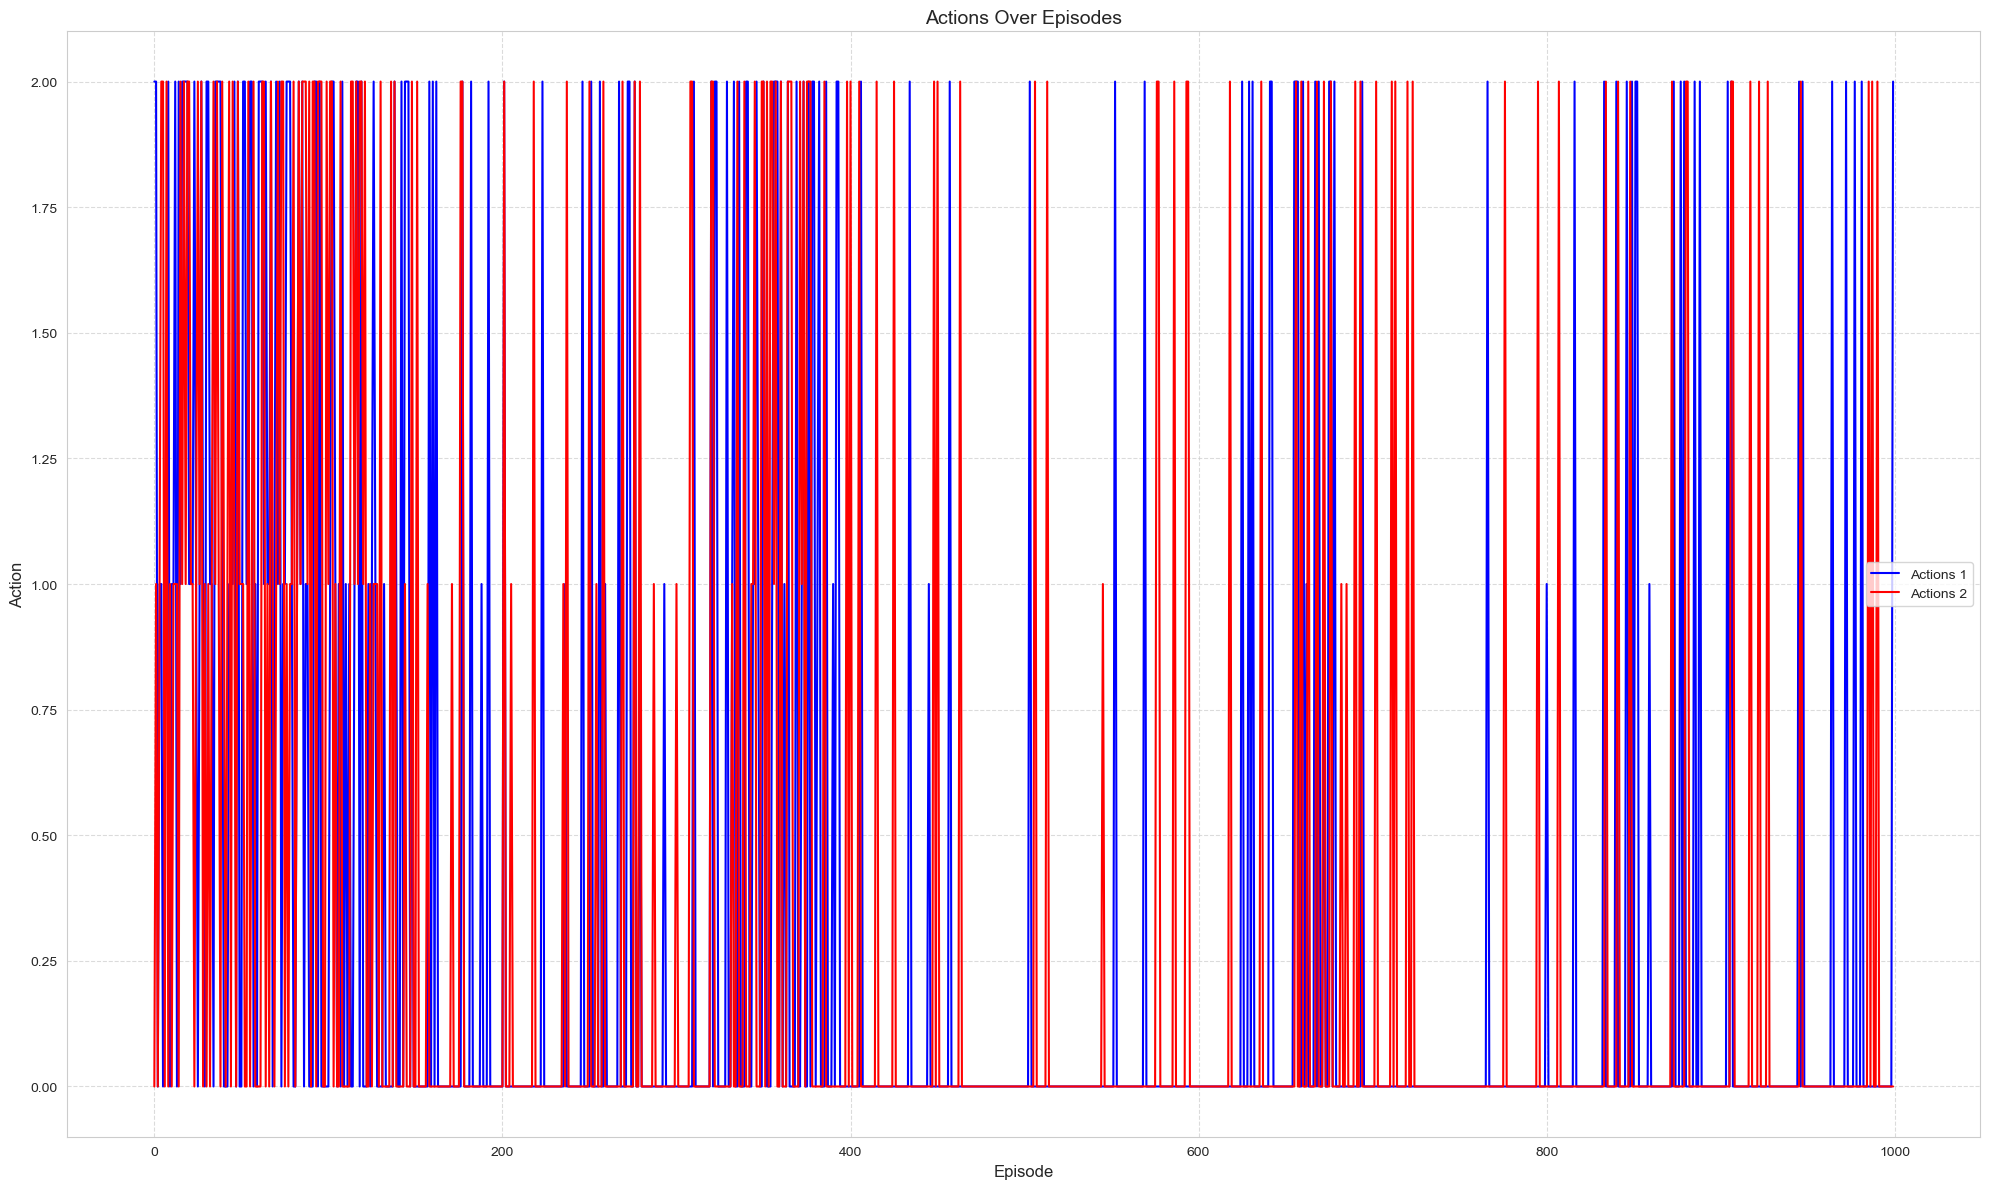

In [9]:
env.close()

## Selfish Agents

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [102.61144022614782, 242.7845050140035, 23.131331884805768], (0, 1): [45.63387472048471, 53.238609597906816, 1625.0235049440234], (1, 0): [75.80419989905809, 7.501956813885908, 94.25462123710773], (1, 1): [77.09947392915632, 80.80271224400482, 35.24361243417456]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 0.
Agent 1 has origin 1 and destination 0.


In [6]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=1, base_class="stable_baselines3")

In [7]:
env.reward_table = []
env.reward_table2 = []
env.actions = []
env.actions2 = []        

In [8]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [13]:
model.learn(total_timesteps=2000)

---------------------------
| time/              |    |
|    fps             | 2  |
|    iterations      | 1  |
|    time_elapsed    | 6  |
|    total_timesteps | 20 |
---------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2            |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 40           |
| train/                  |              |
|    approx_kl            | 0.0051883636 |
|    clip_fraction        | 0.035        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.338       |
|    explained_variance   | -2.04e-05    |
|    learning_rate        | 0.001        |
|    loss                 | 6.11         |
|    n_updates            | 50           |
|    policy_gradient_loss | -0.0235      |
|    value_loss           | 772          |
------------------------------------------
------------------------------

Reward table is:  [-98.23333333333333, -98.25, -14.4, -14.4, -12.9, -14.416666666666666, -98.25, -98.23333333333333, -98.25, -14.416666666666666, -118.11666666666666, -98.25, -118.11666666666666, -14.416666666666666, -14.416666666666666, -98.23333333333333, -14.4, -12.9, -12.9, -98.23333333333333, -12.9, -118.11666666666666, -98.23333333333333, -14.416666666666666, -98.25, -12.9, -12.9, -14.416666666666666, -14.4, -12.9, -98.23333333333333, -12.9, -12.9, -98.23333333333333, -118.03333333333333, -12.9, -12.9, -98.23333333333333, -12.9, -118.06666666666666, -14.416666666666666, -12.9, -12.9, -12.9, -12.9, -12.9, -14.416666666666666, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -98.23333333333333, -12.9, -118.11666666666666, -12.9, -12.9, -98.23333333333333, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -12.9, -14.416666666666666, -12.9, -12.9, -118.11666666666666, -12.9, -12.9, -14.416666666666666, -118.06666666666666, -118.11666666666666, -118.1

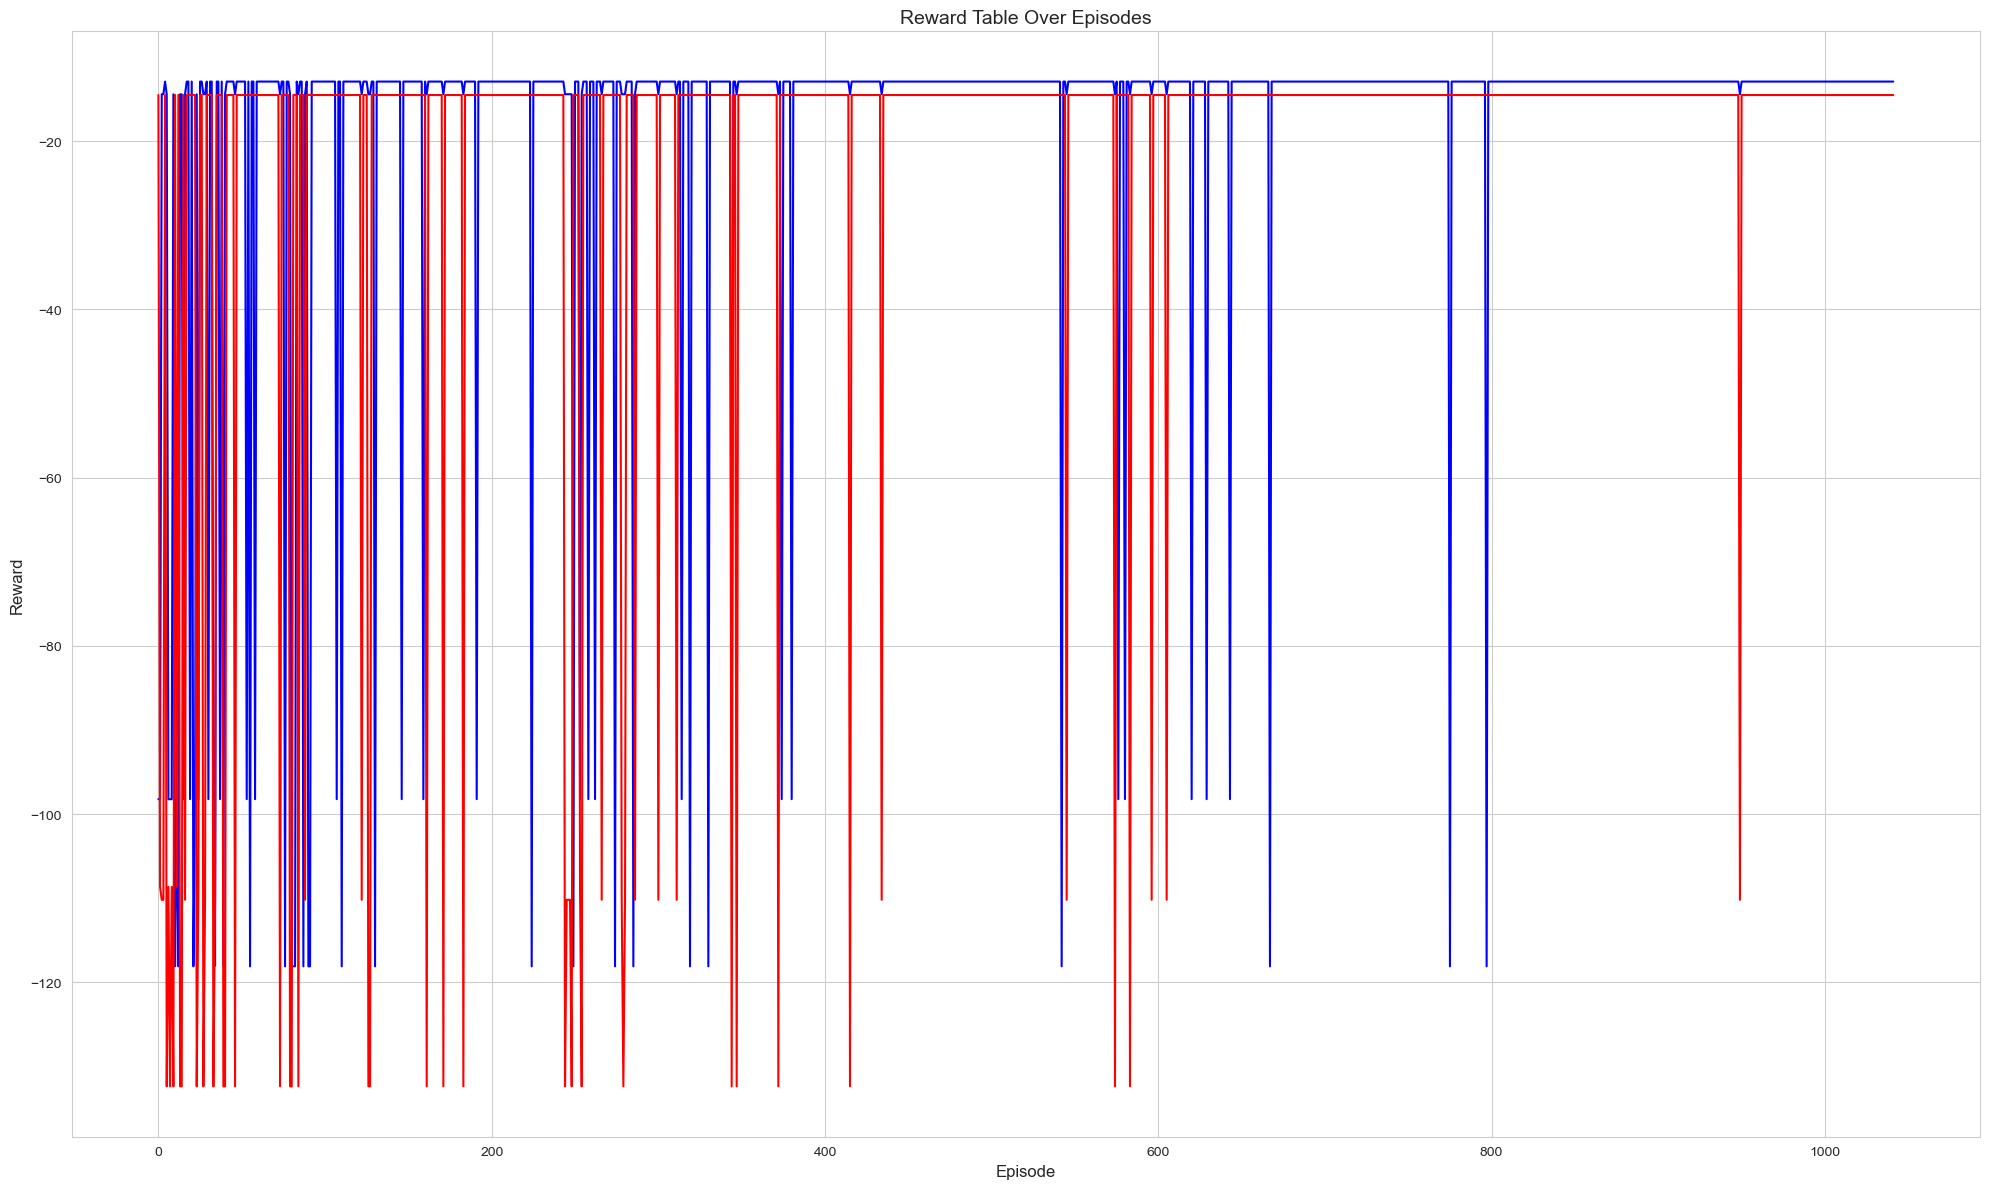

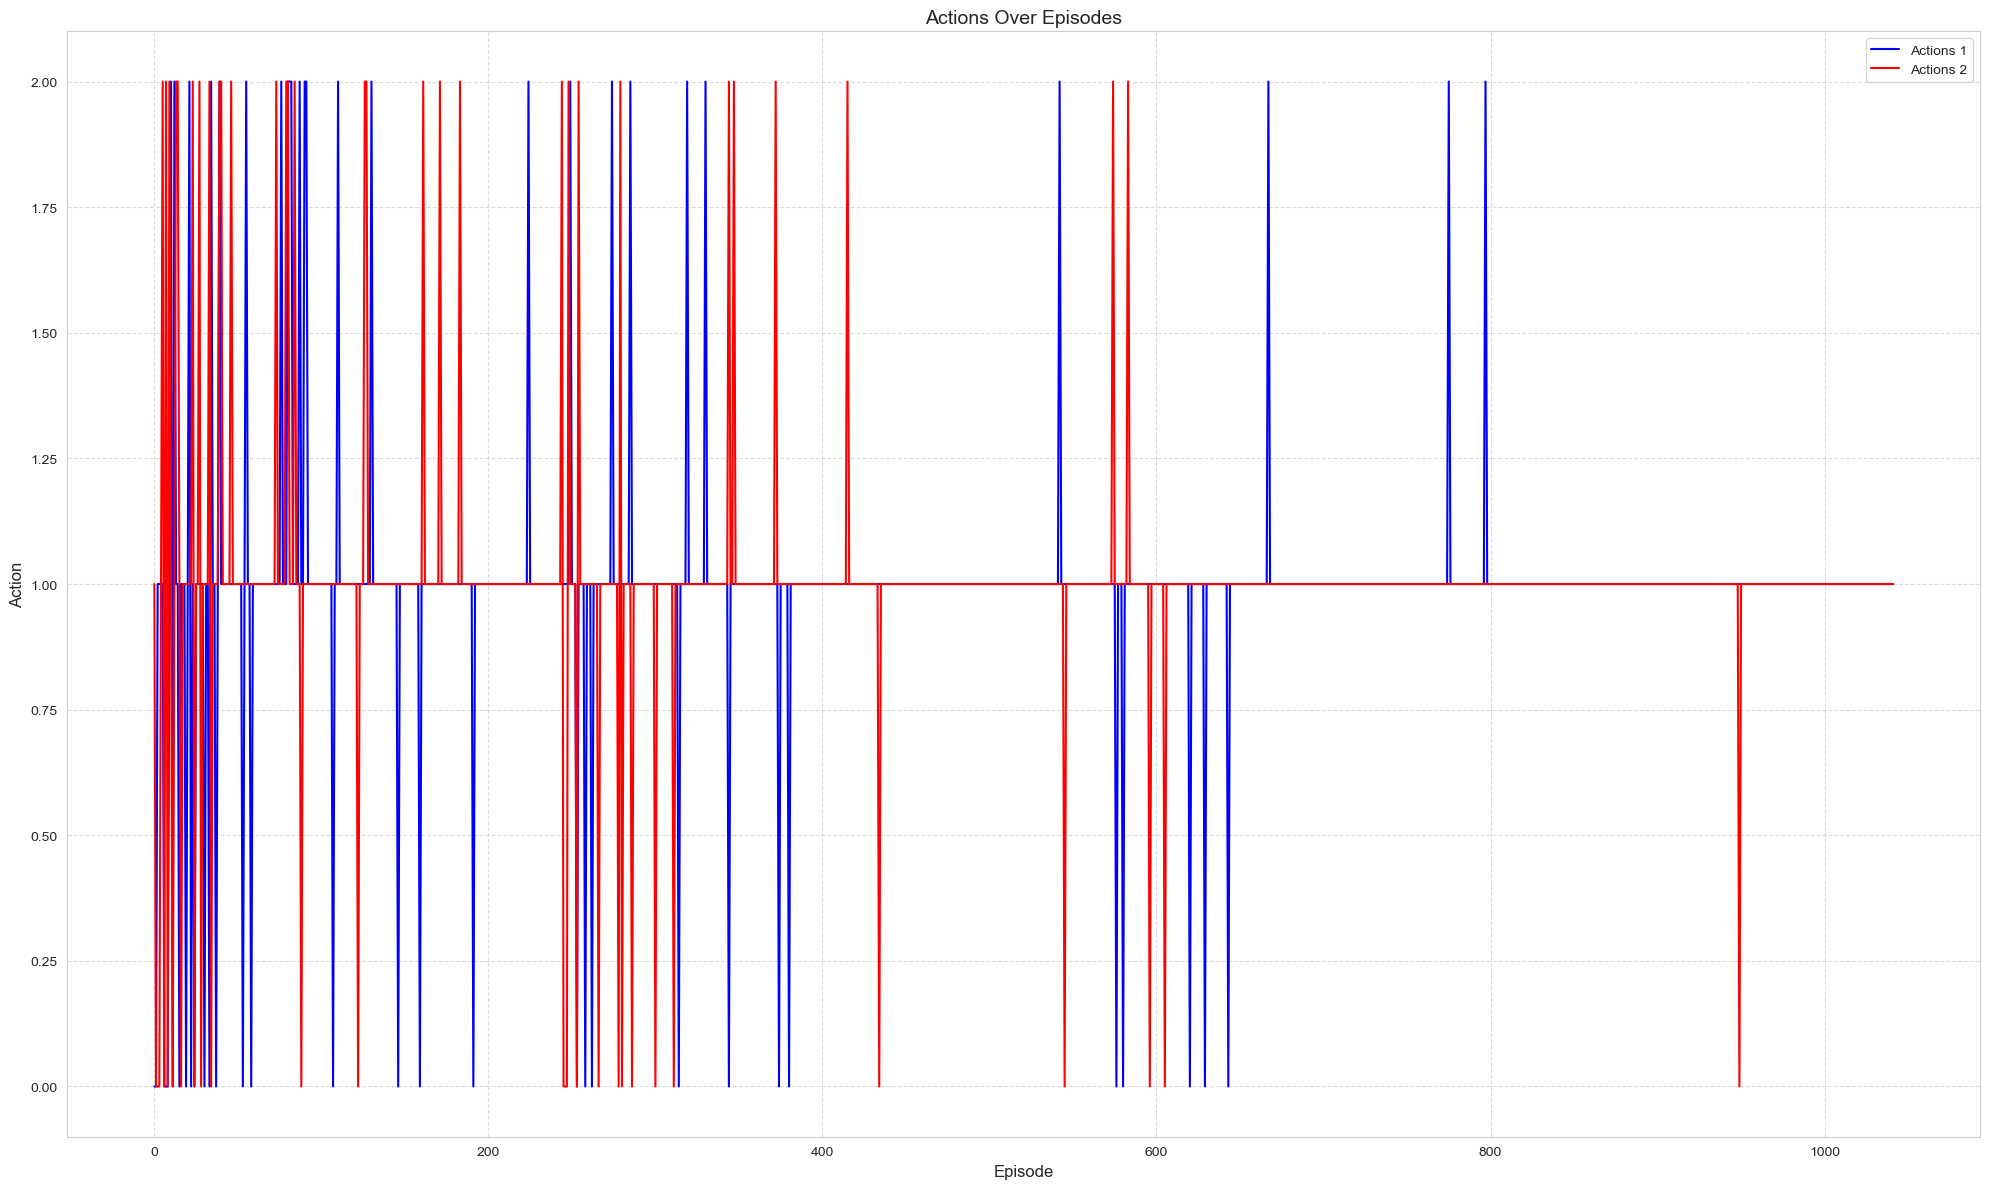

In [14]:
env.close()

## Conclusions

It's important to note that the outcomes we observe in both scenarios are influenced by the calculated free flow travel times associated with each path. The paths generated may vary between environments, leading to different results for each scenario.

In the selfish agents scenario, convergence is observed to occur faster in comparison to the altruistic agents scenario. This happens because in selfish scenarios, each agent focuses only on its own interests, which makes it easier for them to find a solution without having to consider the complex interactions with other agents. In contrast, altruistic agents need to consider the needs and behaviors of multiple agents, which can make the convergence process more difficult and time-consuming.

In terms of training time, it refers to the duration required for the model training process, specifically measured from the execution of model.train().

- Selfish agents: 13 min
- Altrustic agents: 65 minutes